In [ ]:
#neural network
#input layer , hidden layer , neurons , output
# activation output act , loss , optimizer , .. hyper para - we decide value

In [ ]:
#making a toy classification (nn usning py)

In [ ]:
import  sklearn
from sklearn.datasets import make_circles

In [ ]:
samples = 10000
x , y = make_circles(samples , noise =0.03 , random_state=42)
x.shape
# list[:5]
print(x[:50])
print(y[:50])

[[ 0.0464692   0.82477834]
 [ 1.00506323 -0.43335153]
 [-0.58348442  0.79452834]
 [ 0.98478298 -0.32517879]
 [ 0.82993028 -0.54722305]
 [-0.13392877  0.77624858]
 [ 0.77919743  0.64581132]
 [ 0.72295477  0.17383084]
 [-0.12180665  0.79695076]
 [ 0.84952936  0.50567829]
 [-0.92287711 -0.31288882]
 [-0.79361121 -0.00376024]
 [ 0.79898908  0.25640185]
 [ 0.54767607  0.61628528]
 [ 0.31622289 -0.9437914 ]
 [ 0.15624893  0.79085892]
 [ 0.74593253  0.68413147]
 [ 0.80240328 -0.08705568]
 [-0.64917126  0.43375609]
 [-0.58042899 -0.54939528]
 [ 0.75026335 -0.07722696]
 [-0.90605949  0.27702302]
 [ 0.8957224  -0.44359421]
 [ 0.63310642 -0.42743648]
 [ 0.96494136 -0.07574955]
 [ 0.84106049 -0.08997784]
 [-0.8088965   0.63264261]
 [-0.45173391 -0.65483749]
 [-0.31486941  0.68678632]
 [ 0.05764292 -0.8072667 ]
 [ 0.93743983  0.41537469]
 [-1.01054793 -0.20008818]
 [ 0.89600174 -0.48036664]
 [ 0.95792138 -0.05714993]
 [-0.36594741 -0.68905828]
 [-0.52405197 -0.92436071]
 [ 0.63657367  0.57077991]
 

In [ ]:
y

array([1, 0, 0, ..., 1, 0, 1])

In [ ]:
import pandas as pd
circles = pd.DataFrame({'x0':x[:,0] , 'x1':x[:,1] , 'y':y})
circles.head()

,x0,x1,y
0,0.046469,0.824778,1
1,1.005063,-0.433352,0
2,-0.583484,0.794528,0
3,0.984783,-0.325179,0
4,0.829930,-0.547223,0


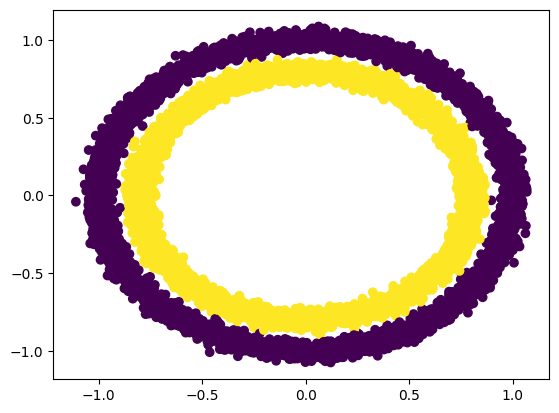

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=x[: , 0], y = x[:,1] , c=y)
# plt.scatter(x=[: , 0], y = x[:,1] , c='r')

In [ ]:
import torch
torch.__version__

'2.10.0+cu128'

In [ ]:
x , y

(array([[ 0.0464692 ,  0.82477834],
        [ 1.00506323, -0.43335153],
        [-0.58348442,  0.79452834],
        ...,
        [ 0.6854581 ,  0.37297955],
        [ 0.47440334,  0.88491997],
        [-0.67440999,  0.26094865]]),
 array([1, 0, 0, ..., 1, 0, 1]))

In [ ]:
x=torch.tensor(x , dtype=torch.float)
y=torch.tensor(y , dtype=torch.float)
x ,y

(tensor([[ 0.0465,  0.8248],
         [ 1.0051, -0.4334],
         [-0.5835,  0.7945],
         ...,
         [ 0.6855,  0.3730],
         [ 0.4744,  0.8849],
         [-0.6744,  0.2609]]),
 tensor([1., 0., 0.,  ..., 1., 0., 1.]))

In [ ]:
torch.manual_seed(42)
from torch import nn

from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

# Reshape y_train and y_test to (batch_size, 1)
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)

len(x_train) , len( x_test )

(8000, 2000)

In [ ]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class CircleModelv1(nn.Module):
  def __init__(self):
    super().__init__()
    #creating the linear layers
    # we want x1 and x2 to map with y thats  y input =2 and outpt =5 just wanted its hyperpara m

    self.layer1 = nn.Linear(in_features=2 , out_features=64)
    #outfeat of previous should match    with  THE INFEATURE  of previous layer
    self.layer2 = nn.Linear(in_features=64 , out_features=1)
#     self.two_linear_layer = nn.Sequential(
#   nn.Linear(in_features=2 , out_features=5),
#   nn.Linear(in_features=5 , out_features=1)
# )
  def forward(self , x):
    return self.layer2(self.layer1(x))

    # return two_linear_layer(x)

model_0 = CircleModelv1()
model_0

CircleModelv1(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
model_0 = nn.Sequential(
  nn.Linear(in_features=2 , out_features=5),
  nn.Linear(in_features=5 , out_features=1)
)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4923,  0.3554],
                      [ 0.3209,  0.5052],
                      [-0.5424,  0.5085],
                      [-0.3343,  0.2624],
                      [ 0.6641, -0.0997]])),
             ('0.bias', tensor([-0.0055, -0.1628, -0.5904,  0.3393, -0.7020])),
             ('1.weight',
              tensor([[ 0.2776,  0.3346,  0.4229, -0.1055, -0.3674]])),
             ('1.bias', tensor([0.1005]))])

In [ ]:
CircleModelv1().state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.3906, -0.7038],
                      [-0.1605, -0.4239],
                      [-0.0618, -0.3480],
                      [-0.2890, -0.2245],
                      [-0.6720,  0.5802],
                      [ 0.5928, -0.1109],
                      [-0.0805, -0.2886],
                      [-0.6386, -0.6881],
                      [ 0.2628, -0.3882],
                      [-0.4546, -0.0552],
                      [-0.2355, -0.2288],
                      [ 0.0227, -0.1500],
                      [-0.2435, -0.3386],
                      [-0.5755,  0.5929],
                      [-0.2830,  0.1874],
                      [-0.2453,  0.0575],
                      [ 0.6592,  0.3258],
                      [-0.6128,  0.2807],
                      [ 0.6712,  0.1860],
                      [ 0.4741,  0.6971],
                      [-0.1083,  0.1468],
                      [-0.4915, -0.1457],
                      [ 0.5237,  0.3625],
   

In [ ]:
import torch.nn.functional as F # Import functional API for leaky_relu

x_test = x_test
y_test = y_test
model_0  # Move the model to the specified device

untrained_preds = model_0(x_test)
len(untrained_preds) , untrained_preds.shape
untrained_preds[:10] , y_test[:10]

# Convert raw predictions to binary labels (0 or 1) using LeakyReLU as requested
untrained_preds_binary = torch.round(F.leaky_relu(untrained_preds))

print(untrained_preds_binary[:10])
print(y_test[:10])

tensor([[0.],
        [-0.],
        [-0.],
        [-0.],
        [1.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [0.]], grad_fn=<SliceBackward0>)
tensor([[1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters() , lr=0.1)

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4923,  0.3554],
                      [ 0.3209,  0.5052],
                      [-0.5424,  0.5085],
                      [-0.3343,  0.2624],
                      [ 0.6641, -0.0997]])),
             ('0.bias', tensor([-0.0055, -0.1628, -0.5904,  0.3393, -0.7020])),
             ('1.weight',
              tensor([[ 0.2776,  0.3346,  0.4229, -0.1055, -0.3674]])),
             ('1.bias', tensor([0.1005]))])

In [ ]:
def accuracy_function(y_true , y_pred):
  correct = torch.eq(y_true , y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [ ]:
#view 5 out of forward pass
with torch.inference_mode():
  y_logits = model_0(x_test)
y_logits

tensor([[ 0.4945],
        [-0.1005],
        [-0.6216],
        ...,
        [ 0.6686],
        [ 0.3848],
        [-0.0179]])

In [ ]:
y_pred_probs = torch.sigmoid(y_logits)
print(y_pred_probs)
y_pred_probs  = torch.round(y_pred_probs)
y_pred_probs


tensor([[0.6212],
        [0.4749],
        [0.3494],
        ...,
        [0.6612],
        [0.5950],
        [0.4955]])


tensor([[1.],
        [0.],
        [0.],
        ...,
        [1.],
        [1.],
        [0.]])

In [ ]:
#training and test a model

epochs = 100

x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)
model_0 = model_0.to(device)

for epoch in range(epochs):
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(x_train) # Removed .squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate loss and accuracy
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_function(y_train, y_preds)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(x_test) # Removed .squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss and accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_function(y_test, test_preds)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train Loss: {loss:.4f} Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.7152 Acc: 50.49% | Test Loss: 0.7205 Acc: 49.25%
Epoch: 10 | Train Loss: 0.7085 Acc: 50.45% | Test Loss: 0.7130 Acc: 49.50%
Epoch: 20 | Train Loss: 0.7041 Acc: 50.20% | Test Loss: 0.7080 Acc: 49.25%
Epoch: 30 | Train Loss: 0.7011 Acc: 50.35% | Test Loss: 0.7045 Acc: 48.90%
Epoch: 40 | Train Loss: 0.6991 Acc: 50.30% | Test Loss: 0.7020 Acc: 49.05%
Epoch: 50 | Train Loss: 0.6976 Acc: 50.21% | Test Loss: 0.7002 Acc: 49.00%
Epoch: 60 | Train Loss: 0.6965 Acc: 50.26% | Test Loss: 0.6988 Acc: 48.90%
Epoch: 70 | Train Loss: 0.6957 Acc: 50.35% | Test Loss: 0.6978 Acc: 48.65%
Epoch: 80 | Train Loss: 0.6952 Acc: 50.54% | Test Loss: 0.6970 Acc: 48.70%
Epoch: 90 | Train Loss: 0.6947 Acc: 50.46% | Test Loss: 0.6964 Acc: 48.80%


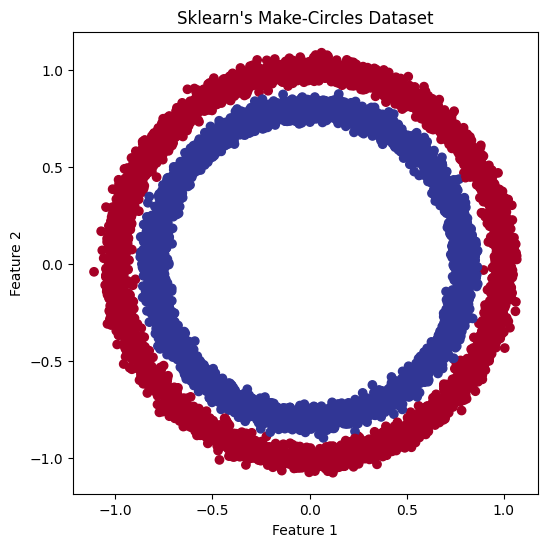

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Sklearn's Make-Circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

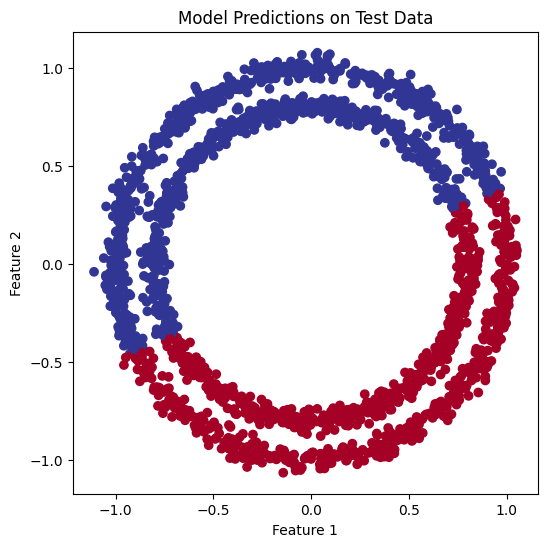

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(x_test[:, 0].cpu(), x_test[:, 1].cpu(), c=test_preds.cpu(), cmap=plt.cm.RdYlBu)
plt.title("Model Predictions on Test Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4538,  0.3072],
                      [ 0.3841,  0.4223],
                      [-0.4786,  0.4275],
                      [-0.3690,  0.3107],
                      [ 0.6047, -0.0232]], device='cuda:0')),
             ('0.bias',
              tensor([-0.0058, -0.1631, -0.5909,  0.3394, -0.7016], device='cuda:0')),
             ('1.weight',
              tensor([[ 0.0951,  0.2821,  0.1972, -0.2520, -0.2234]], device='cuda:0')),
             ('1.bias', tensor([0.0995], device='cuda:0'))])

-------------------CREATING THE NEW MODEL -------------------------

In [ ]:
accuracy_function  , loss_fn , optimizer

(<function __main__.accuracy_function(y_true, y_pred)>,
 BCEWithLogitsLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [ ]:
class CircleModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1=nn.Linear(in_features=2 , out_features=10)
    self.layer2= nn.Linear(in_features=10 , out_features=10)
    self.layer3=nn.Linear(in_features=10 , out_features=1)

  def forward(self , x):
    z=self.layer1(x)
    # z=torch.relu(z)
    z=self.layer2(z)
    return self.layer3(z)

model_1=CircleModelv2().to(device)
model_1

CircleModelv2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1.parameters() , lr=0.01)



In [ ]:
torch.manual_seed(42)
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)

epochs =100
for epoch in range(epochs):
  model_1.train()
  y_logits=model_1(x_train)
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits , y_train)
  acc = accuracy_function(y_train , y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(x_test)
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits , y_test)
    test_acc = accuracy_function(y_test , test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Train Loss: {loss:.4f} Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} Acc: {test_acc:.2f}%")

Epoch: 0 | Train Loss: 0.6944 Acc: 51.95% | Test Loss: 0.6940 Acc: 52.40%
Epoch: 10 | Train Loss: 0.6944 Acc: 51.71% | Test Loss: 0.6940 Acc: 52.05%
Epoch: 20 | Train Loss: 0.6944 Acc: 51.56% | Test Loss: 0.6939 Acc: 52.05%
Epoch: 30 | Train Loss: 0.6943 Acc: 51.49% | Test Loss: 0.6939 Acc: 52.05%
Epoch: 40 | Train Loss: 0.6943 Acc: 51.45% | Test Loss: 0.6938 Acc: 52.15%
Epoch: 50 | Train Loss: 0.6943 Acc: 51.40% | Test Loss: 0.6938 Acc: 51.95%
Epoch: 60 | Train Loss: 0.6942 Acc: 51.35% | Test Loss: 0.6938 Acc: 52.00%
Epoch: 70 | Train Loss: 0.6942 Acc: 51.26% | Test Loss: 0.6937 Acc: 51.90%
Epoch: 80 | Train Loss: 0.6942 Acc: 51.16% | Test Loss: 0.6937 Acc: 52.15%
Epoch: 90 | Train Loss: 0.6941 Acc: 51.05% | Test Loss: 0.6937 Acc: 52.05%
